### Import statement

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from netCDF4 import Dataset

from cmcrameri import cm
import scienceplots
plt.style.use(['science', 'no-latex'])  # Use 'science' style without LaTeX rendering
plt.rcParams.update({"font.size":15})

In [39]:
nc_file_path = "/home/marijn/LovePy/fwlLove.jl/out/obliqua_data.nc"
interior_dat = "/home/marijn/PROTEUS/Obliqua_data/output272353.0.json"
out_dir      = "/home/marijn/LovePy/fwlLove.jl/out"

if not os.path.exists(nc_file_path):
    raise FileNotFoundError(f"Could not find NetCDF file at {nc_file_path}")
    
ds = Dataset(nc_file_path, "r")
os.makedirs(out_dir, exist_ok=True)

### Plot Global Love numbers

In [40]:
def plot_imagk2_spectrum(sigma_range, imag_k2, n=2, outpath=None):
    """
    Plots the Imk2 Love numbers with a detailed, 
    custom loglog-style grid matrix.
    """
    # manually compute logs for linear scattering
    sigma_range = np.log10(np.abs(sigma_range))
    imag_k2     = np.log10(np.abs(imag_k2))
                           
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.scatter(sigma_range, imag_k2) 
        
    ax.set_title(r"Imag($k_{" + str(n) + r"}$) Spectrum")
    ax.set_xlabel(r"$\log_{10}(\sigma)$ [Hz]")
    ax.set_ylabel(r"$\log_{10}(\text{Imag}(k_{" + str(n) + r"}))$")
    
    # SYNTHETIC LOG-LOG GRID MATRICES
    # major ticks at every whole decade integer (-1.0, -2.0, etc.)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    
    # minor ticks to simulate log-spacing intervals between decades
    # log10 of intermediate steps (2, 3, 4...) approximate these fractional steps:
    log_subs = np.log10([2, 3, 4, 5, 6, 7, 8, 9])
    
    # generate ticks across the typical log-data spectrum dynamically
    minor_ticks_x = np.concatenate([np.arange(np.floor(sigma_range.min()), np.ceil(sigma_range.max())) + sub for sub in log_subs])
    minor_ticks_y = np.concatenate([np.arange(np.floor(imag_k2.min()), np.ceil(imag_k2.max())) + sub for sub in log_subs])
    
    ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_ticks_x))
    ax.yaxis.set_minor_locator(ticker.FixedLocator(minor_ticks_y))
    
    # render major lines solid and distinct; minor lines fine and tightly grouped
    ax.grid(True, which="major", ls="-", color='#444444', alpha=0.4, zorder=1)
    ax.grid(True, which="minor", ls=":", color='#888888', alpha=0.25, zorder=1)
    
    ax.legend(loc="best")
        
    if outpath:
        fig.savefig(outpath, dpi=200, bbox_inches='tight')
    plt.show()
    return fig

/tmp/ipykernel_2410350/3745996484.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


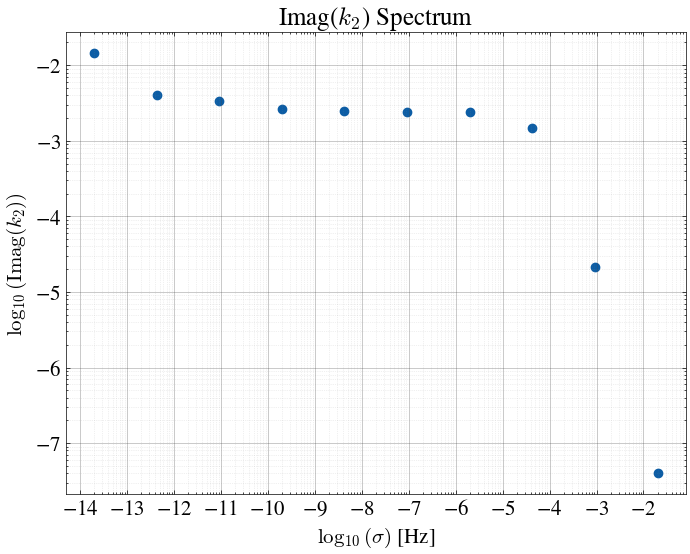

In [41]:
# read shared dimensions
sigma_range = ds.variables["sigma_range"][:]
n           = ds.variables["n"][:]

# extract and run plot
raw_imag   = ds.variables["knms_total"]
knms_total = raw_imag[0, :] + 1j * raw_imag[1, :]

# loop over unique n values and plot each spectrum separately
for n_i in np.unique(n):

    knms_total_n = knms_total[n == n_i]

    fig = plot_imagk2_spectrum(
        sigma_range=sigma_range, 
        imag_k2=-np.imag(knms_total_n), 
        n=n_i,
        outpath=os.path.join(out_dir, f"all_layers_k{n_i}.png")
    )

### Plot Section-wise Love Numbers

In [42]:
def plot_imagk2_spectra(sigma_range, imag_k2, segments, n=2, outpath=None):
    """
    Plots the segment-wise Imk2 Love numbers with a detailed, 
    custom loglog-style grid matrix.
    """
    # manually compute logs for linear scattering
    sigma_range = np.log10(np.abs(sigma_range))
    imag_k2     = np.log10(np.abs(imag_k2))
                           
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = cm.batlow(np.linspace(0, 1, len(segments)))
    
    for idx, seg_name in enumerate(segments):
        ax.scatter(sigma_range, imag_k2[idx, :], label=seg_name, 
                  color=colors[idx], s=50, zorder=3) # zorder keeps points on top of grid lines
        
    ax.set_title(r"Imag($k_{" + str(n) + r"}$) Spectrum")
    ax.set_xlabel(r"$\log_{10}(\sigma)$ [Hz]")
    ax.set_ylabel(r"$\log_{10}(\text{Imag}(k_{" + str(n) + r"}))$")
    
    # SYNTHETIC LOG-LOG GRID MATRICES
    # major ticks at every whole decade integer (-1.0, -2.0, etc.)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    
    # minor ticks to simulate log-spacing intervals between decades
    # log10 of intermediate steps (2, 3, 4...) approximate these fractional steps:
    log_subs = np.log10([2, 3, 4, 5, 6, 7, 8, 9])
    
    # generate ticks across the typical log-data spectrum dynamically
    minor_ticks_x = np.concatenate([np.arange(np.floor(sigma_range.min()), np.ceil(sigma_range.max())) + sub for sub in log_subs])
    minor_ticks_y = np.concatenate([np.arange(np.floor(imag_k2.min()), np.ceil(imag_k2.max())) + sub for sub in log_subs])
    
    ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_ticks_x))
    ax.yaxis.set_minor_locator(ticker.FixedLocator(minor_ticks_y))
    
    # render major lines solid and distinct; minor lines fine and tightly grouped
    ax.grid(True, which="major", ls="-", color='#444444', alpha=0.4, zorder=1)
    ax.grid(True, which="minor", ls=":", color='#888888', alpha=0.25, zorder=1)
    
    ax.legend(loc="best")
        
    if outpath:
        fig.savefig(outpath, dpi=200, bbox_inches='tight')
    plt.show()
    return fig

In [43]:
def plot_imagk2_spectra(sigma_range, imag_k2, segments, n=2, outpath=None):
    """
    Plot segment-wise Imag(k_n) spectra using connected lines with
    small markers at the exact datapoints.

    Parameters
    ----------
    sigma_range : array-like
        Frequency values.
    imag_k2 : 2D array-like
        Imaginary Love number spectra with shape (n_segments, n_points).
    segments : list[str]
        Labels for each segment.
    n : int
        Love number degree.
    outpath : str or None
        Optional save path.
    """

    # manually compute logs for linear plotting
    sigma_log = np.log10(np.abs(sigma_range))
    imag_log  = np.log10(np.abs(imag_k2))

    fig, ax = plt.subplots(figsize=(8, 6))

    colors = cm.batlow(np.linspace(0, 1, len(segments)))

    # --- sort once to ensure clean connected lines ---
    sort_idx = np.argsort(sigma_log)
    sigma_sorted = sigma_log[sort_idx]

    for idx, seg_name in enumerate(segments):

        y_sorted = imag_log[idx, sort_idx]

        # Main smooth line
        ax.plot(
            sigma_sorted,
            y_sorted,
            label=seg_name,
            color=colors[idx],
            lw=2.0,
            zorder=2,
        )

        # Small datapoint markers
        ax.plot(
            sigma_sorted,
            y_sorted,
            linestyle="None",
            marker="o",
            markersize=3,
            color=colors[idx],
            alpha=0.8,
            zorder=3,
        )

    ax.set_title(r"Imag($k_{" + str(n) + r"}$) Spectrum")
    ax.set_xlabel(r"$\log_{10}(\sigma)$ [Hz]")
    ax.set_ylabel(r"$\log_{10}(\mathrm{Imag}(k_{" + str(n) + r"}))$")

    # --- synthetic log-style grid ---
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))

    log_subs = np.log10([2, 3, 4, 5, 6, 7, 8, 9])

    x_decades = np.arange(
        np.floor(sigma_sorted.min()),
        np.ceil(sigma_sorted.max())
    )

    y_decades = np.arange(
        np.floor(imag_log.min()),
        np.ceil(imag_log.max())
    )

    minor_ticks_x = np.concatenate(
        [x_decades + sub for sub in log_subs]
    )

    minor_ticks_y = np.concatenate(
        [y_decades + sub for sub in log_subs]
    )

    ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_ticks_x))
    ax.yaxis.set_minor_locator(ticker.FixedLocator(minor_ticks_y))

    # Grid styling
    ax.grid(
        True,
        which="major",
        ls="-",
        color="#444444",
        alpha=0.4,
        zorder=1,
    )

    ax.grid(
        True,
        which="minor",
        ls=":",
        color="#888888",
        alpha=0.25,
        zorder=1,
    )

    ax.legend(loc="best")

    if outpath:
        fig.savefig(outpath, dpi=200, bbox_inches="tight")

    plt.show()

    return fig

/tmp/ipykernel_2410350/195555777.py:22: RuntimeWarning: divide by zero encountered in log10
  imag_log  = np.log10(np.abs(imag_k2))


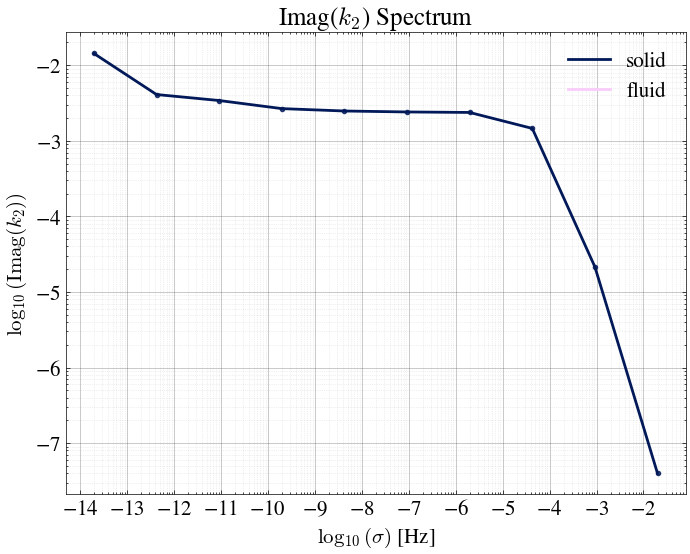

In [44]:
# read shared dimensions
sigma_range = ds.variables["sigma_range"][:]
n           = ds.variables["n"][:]

# extract and run plot
raw_imag = ds.variables["knms_T"]
Knms_T   = raw_imag[0, :, :] + 1j * raw_imag[1, :, :]
segments = ds.variables["segment_lbl"][:]

# loop over unique n values and plot each spectrum separately
for n_i in np.unique(n):

    Knms_T_n = Knms_T[:, n == n_i]

    fig = plot_imagk2_spectra(
        sigma_range=sigma_range, 
        imag_k2=-np.imag(Knms_T_n), 
        segments=segments,
        n=n_i,
        outpath=os.path.join(out_dir, f"all_layers_k{n_i}.png")
    )

### Plot Heating profile per forcing frequency

In [ ]:
def plot_segment_heating(
    H,
    sigma_range,
    radius=None,
    mask_floor=1e-25,
    rotation_angle=60,
    outpath=None,
    title_str="Heating profile"
):
    """
    Heatmap of tidal heating across radius and forcing frequency.
    Radius axis is now physical (if provided).
    """

    import numpy as np
    import matplotlib.pyplot as plt

    Nz = H.shape[0]

    # compute log frequencies
    actual_log_sigmas = np.log10(np.abs(sigma_range))
    bar_indices = np.arange(len(sigma_range))

    if radius is None:
        r_norm = np.linspace(0.01, 1.0, Nz)
        y_label = "Modeled radius fraction (r / R)"
    else:
        r = np.asarray(radius)

        # normalize to planet radius if not already
        if np.nanmax(r) > 1.5:
            r_norm = r / np.nanmax(r)
        else:
            r_norm = r

        y_label = "Radius fraction (r / R)"

    # ensure shape safety
    H_mat = np.maximum(H, mask_floor)

    fig, ax = plt.subplots(figsize=(9, 5))

    X, Y = np.meshgrid(bar_indices, r_norm)

    mesh = ax.pcolormesh(
        X, Y, np.log10(H_mat),
        cmap=cm.lajolla,
        shading="auto"
    )

    # x-axis tick handling
    max_labels = 10
    tick_indices = np.linspace(
        0,
        len(sigma_range) - 1,
        min(max_labels, len(sigma_range)),
        dtype=int
    )

    ax.set_xticks(tick_indices)

    tick_labels = [f"{actual_log_sigmas[idx]:.2f}" for idx in tick_indices]
    ax.set_xticklabels(tick_labels, rotation=rotation_angle, ha="right")

    ax.set_title(title_str)
    ax.set_xlabel(r"Forcing frequency ($\log_{10}(\sigma)$ [Hz])")
    ax.set_ylabel(y_label)

    ax.invert_xaxis()

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(r"$\log_{10}$ [W m$^{-3}$] (tidal heating)")

    if outpath:
        fig.savefig(outpath, dpi=200, bbox_inches="tight")

    plt.show()
    return fig

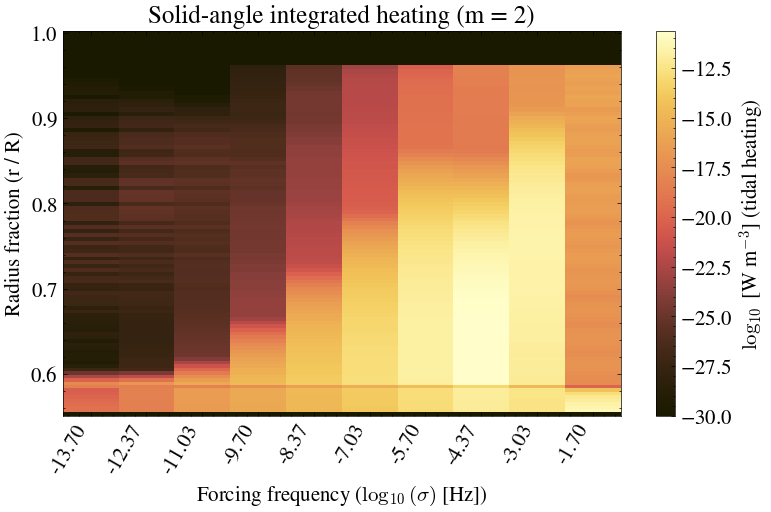

In [ ]:
import numpy as np
import os

# read shared dimensions
sigma_range = ds.variables["sigma_range"][:]
m = ds.variables["m"][:]

P_T_s_glb = (ds.variables["P_T_s_glb_μ"][:] +
             ds.variables["P_T_s_glb_κ"][:] +
             ds.variables["P_T_s_glb_l"][:])  # (nmk, lon, lat, z)

r = ds.variables["radius"][:]

lat = ds.variables["lat"][:]
lon = ds.variables["lon"][:]

dlat = np.deg2rad(np.abs(lat[1] - lat[0]))
dlon = np.deg2rad(np.abs(lon[1] - lon[0]))

# weights for latitude
lat_rad = np.deg2rad(lat)
weights_lat = np.sin(lat_rad)[None, None, :, None]  # (1,1,lat,1)

# solid angle integration
H_solid = np.sum(
    P_T_s_glb * weights_lat,
    axis=(1, 2)   # integrate lon and lat
) * dlat * dlon

# radius normalization (planet fraction)
r_mid = 0.5 * (r[:-1] + r[1:])
r_frac = r_mid / np.max(r_mid)

# loop over unique m values and plot each spectrum separately
for m_i in np.unique(m):

    idx = (m == m_i)

    # select heating profiles for this m
    H_i = H_solid[:, idx]
    sigma_range_i = sigma_range[idx]

    fig = plot_segment_heating(
        H=H_i,
        sigma_range=sigma_range_i,
        radius=r_frac,
        mask_floor=1e-30,
        outpath=os.path.join(out_dir, f"tidal_heating_map_m{m_i}.png"),
        title_str=f"Solid-angle integrated heating (m = {m_i})"
    )

### Plot heating profile

In [ ]:
def plot_heating_combined(
    profiles_dict,
    radius=None,
    mask_floor=1e-25,
    outpath=None,
    title_str="Heating profiles breakdown"
):
    """
    Plots multiple radial heating profiles (frequency-integrated) on a single figure.
    Expects profiles_dict to be a dict of {label: H_z_array}.
    """
    # get Nz from the first item in the dictionary
    first_profile = next(iter(profiles_dict.values()))
    Nz = first_profile.shape[0]

    if radius is None:
        r = np.linspace(0.01, 1.0, Nz)
        xlab = "Modeled radius fraction (r / R)"
    else:
        r = np.asarray(radius)
        r = r / np.max(r)
        xlab = "Radius fraction (r / R)"

    fig, ax = plt.subplots(figsize=(9, 5))
    
    # loop through the dictionary and plot each line
    for name, H in profiles_dict.items():
        H_clipped = np.maximum(H, mask_floor)
        logH = np.log10(H_clipped)
        
        # give the 'total' line a distinct look (thicker/dashed) if present
        if name.lower() == "total":
            ax.plot(r, logH, label=name.replace("_", " ").title(), linewidth=2.5, linestyle="--", color="black")
        else:
            ax.plot(r, logH, label=name.replace("_", " ").title(), linewidth=1.5)

    ax.set_title(title_str)
    ax.set_xlabel(xlab)
    ax.set_ylabel(r"Heating (log$_{10}$ [W m$^{-3}$])")
    
    ax.set_ylim(bottom=np.log10(mask_floor))
    ax.legend(loc="best")
    ax.grid(True, linestyle=":", alpha=0.6)

    if outpath:
        fig.savefig(outpath, dpi=200, bbox_inches="tight")

    plt.show()
    return fig

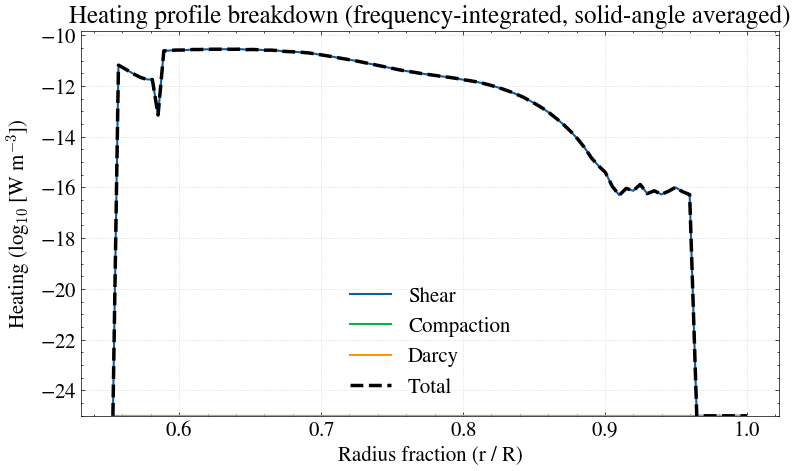

In [ ]:
# load data arrays
raw_components = {
    "shear": ds.variables["P_T_s_glb_μ"][:],
    "compaction": ds.variables["P_T_s_glb_κ"][:],
    "darcy": ds.variables["P_T_s_glb_l"][:]
}
raw_components["total"] = raw_components["shear"] + raw_components["compaction"] + raw_components["darcy"]

# grid setup
lat = ds.variables["lat"][:]
lon = ds.variables["lon"][:]
r = ds.variables["radius"][:]

dlat = np.deg2rad(np.abs(lat[1] - lat[0]))
dlon = np.deg2rad(np.abs(lon[1] - lon[0]))

lat_rad = np.deg2rad(lat)
weights_lat = np.sin(lat_rad)[None, None, :, None]  # (1, 1, lat, 1)

r_mid = 0.5 * (r[:-1] + r[1:])
r_frac = r_mid / np.max(r_mid)
Nz = len(r_mid)

# process integration for all profiles
integrated_profiles = {}

for name, P_T_s_glb in raw_components.items():
    # solid-angle integration over lon (axis 1) and lat (axis 2)
    P_T_prf = np.sum(P_T_s_glb * weights_lat, axis=(1, 2)) * dlat * dlon
    
    # mode/frequency axis integration based on orientation
    if P_T_prf.shape[0] == Nz:
        H_z = np.sum(P_T_prf, axis=1)
    elif P_T_prf.shape[1] == Nz:
        H_z = np.sum(P_T_prf, axis=0)
    else:
        raise ValueError(f"Unexpected shape for P_T_prf: {P_T_prf.shape}")
        
    # store the 1D line array
    integrated_profiles[name] = H_z

# generate the combined figure
fig = plot_heating_combined(
    profiles_dict=integrated_profiles,
    radius=r_frac,
    mask_floor=1e-25,
    outpath=os.path.join(out_dir, "tidal_heating_combined_breakdown.png"),
    title_str="Heating profile breakdown (frequency-integrated, solid-angle averaged)"
)

### Plot Surface heating map

In [ ]:
def plot_surface_heating(H_surf_raw, lons, lats, outpath=None, title_str="Surface heating map"):
    """
    Creates a map layout of surface tidal heating across longitude and latitude coordinates.
    """
    H_surf = np.log10(H_surf_raw.T)
        
    fig, ax = plt.subplots(figsize=(10, 5))
    mesh = ax.pcolormesh(lons, lats, H_surf, cmap=cm.lajolla, shading='auto')
    
    ax.set_title(title_str)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect('equal')
    
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(r"$log_{10}$(surface heating)")
    
    if outpath:
        fig.savefig(outpath, dpi=200, bbox_inches='tight')
    plt.show()
    return fig

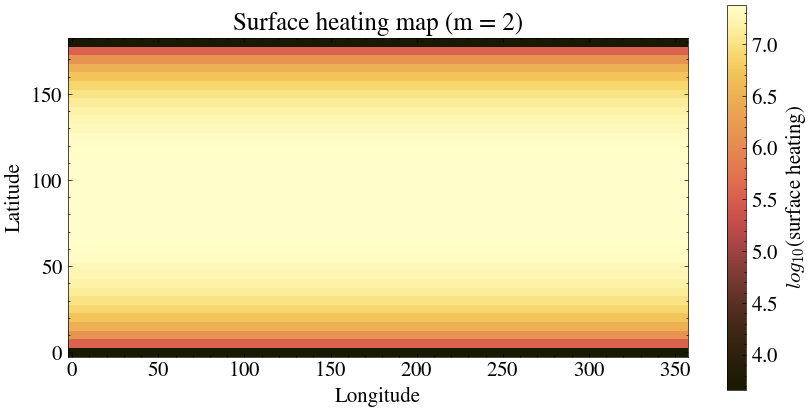

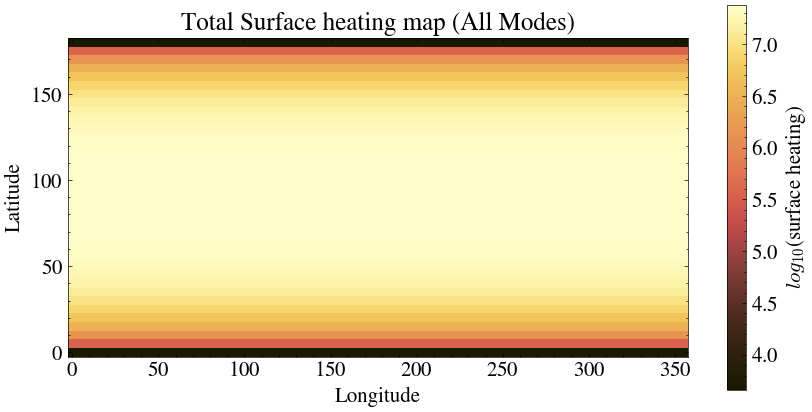

In [ ]:
# read shared dimensions and variables
sigma_range = ds.variables["sigma_range"][:]
m = ds.variables["m"][:]
P_T_s_glb = ds.variables["P_T_s_glb_μ"][:]  # Shape: (z, lon, lat, modes)

r = ds.variables["radius"][:]
lat = ds.variables["lat"][:]
lon = ds.variables["lon"][:]

# prepare radial midpoints and weights (dr)
r_mid = 0.5 * (r[:-1] + r[1:])
dr = np.diff(r)

# shape weights to match axis 0 (radial dimension z)
radial_weights = (r_mid**2 * dr)[:, None, None, None]

# perform the radial integration over axis=0 (z)
H_radial_integrated = np.sum(P_T_s_glb * radial_weights, axis=0)

# loop over unique m values, sum their specific modes, and plot
for m_i in np.unique(m):

    # boolean mask for the current m wave-number
    idx = (m == m_i)
    
    # filter and sum across the mode axis (axis 2) for this specific m
    summed_map = np.sum(H_radial_integrated[:, :, idx], axis=2)
    
    # generate the surface plot for individual m
    fig = plot_surface_heating(
        H_surf_raw=summed_map, 
        lons=lon,               
        lats=lat,               
        outpath=os.path.join(out_dir, f"tidal_heating_map_surface_m_{m_i}.png"),
        title_str=f"Surface heating map (m = {m_i})"
    )

# sum over ALL modes (nmk) to get the total heating map
total_summed_map = np.sum(H_radial_integrated, axis=2)

# generate the global total surface plot
fig_total = plot_surface_heating(
    H_surf_raw=total_summed_map, 
    lons=lon,               
    lats=lat,               
    outpath=os.path.join(out_dir, "tidal_heating_map_surface_total_all_m.png"),
    title_str="Total Surface heating map (All Modes)"
)

### Gloabl 3d Heating